# Explore LipiNet

## Setup

### Load Dependencies

In [1]:
from graph_tool.all import Graph, GraphView, graph_draw
import graph_tool as gt

from onionnet import OnionNet
import onionnet.visualisation

import pandas as pd

from onionnet.property_manager import OnionNetPropertyManager
from onionnet.analytics import layer_stats, plot_layer_metagraph, _infer_family_basic

import onionnet
# … make changes to onionnet/core.py, builder.py, etc. on disk …
import importlib
importlib.reload(onionnet)
# If you also need to reload its submodules:
import onionnet.core, onionnet.builder, onionnet.searcher, onionnet.property_manager
importlib.reload(onionnet.core)
importlib.reload(onionnet.builder)
importlib.reload(onionnet.searcher)
importlib.reload(onionnet.property_manager)

<module 'onionnet.property_manager' from '/Users/agjanyunlu/Documents/Metabolomics/onionnet/onionnet/property_manager.py'>

### Load LipiNet data

First, we begin by loading the necessary data for LipiNet, available in a function that compiles the node and edge dataframes from each of the parsed input sources. Currently:
- SwissLipids
- Rhea

If this is your first time running this it may take a few minutes to download from each of the sources and parse the data. 🐢

We recommend you set `use_cache=True` so that subsequent runs can load the preprocessed data much faster (should load in ~5 seconds). 🐇

Optionally, you can `force_download` from the original sources, but we recommend only doing this every now and then, when you want the latest resources.

In [2]:
from lipinet.build_lipinet import build_lipinet_data

lipinet_data = build_lipinet_data(verbose=True, use_cache=True, force_download=False)
df_nodes = lipinet_data['df_nodes']
df_edges = lipinet_data['df_edges'] 

↪ Loading LipiNet (combined) from cache


Now simply build the network from the node and edges, a super easy process with `OnionNet`. This should only take just over a minute.

In [3]:
onion = OnionNet()

onion.grow_onion(df_nodes=df_nodes,
           df_edges=df_edges,
           node_prop_cols=df_nodes.columns.to_list(),
           edge_prop_cols=df_edges.columns.to_list(),
           drop_na=True,
           drop_duplicates=True)

Nodes: in=2817072, dropped_na=0, deduped=0 → final=2817072
Edges: in=7002161, dropped_invalid=10222, deduped=0 → final=6991939


That's it, now we have loaded the processed LipiNet data and created a multilayered network from all the resources using OnionNet. Let's dig in! 🤓

## Explore LipiNet

### Inspecting the LipiNet MetaGraph

Here we will begin our exploration by creating a _MetaGraph_ of LipiNet, from the `layers`.

To do this we will first inspect node and edge stats using the OnionNet `layer_stats()` function.

In [4]:
nodes_by_layer, edges_by_pair = layer_stats(
    df_nodes=df_nodes,
    df_edges=df_edges,
    print_tables=True
)


Node counts by layer:


,count
layer,
swisslipids,779312
sl_abbreviation,736949
sl_synonyms,534781
sl_metanetx,504880
sl_parent,184620
rhea_reactionid,17783
sl_hmdb,17232
rhea_chebiid,13723
sl_lipidmaps,12112



Interlayer edge count: 6114475
Edge counts by (source_layer, target_layer):


edges
source_layer    target_layer                 
swisslipids     sl_components         1852844
                sl_components_parsed  1852844
                sl_abbreviation        786750
                swisslipids            779247
                sl_synonyms            568257
                sl_metanetx            505003
                sl_parent              493491
rhea_reactionid rhea_chebiid            83885
swisslipids     sl_hmdb                 26026
rhea_reactionid rhea_ec                 18072
swisslipids     sl_lipidmaps            12117
                sl_pmid                 10109
rhea_ec         rhea_ec                  6482
swisslipids     sl_chebi                 4278
sl_chebi        rhea_chebiid             2756

Now we will use the OnionNet `plot_layer_metagraph()` function to get the MetaGraph. 

As a small helper function we will colour the MetaGraph by swisslipids or rhea layers.

In [5]:
def my_family(name: str) -> str:
    n = (name or "").lower()
    if n.startswith(("sl_", "swisslipids")): return "sl"
    if n.startswith("rhea"): return "rhea"
    return _infer_family_basic(n)

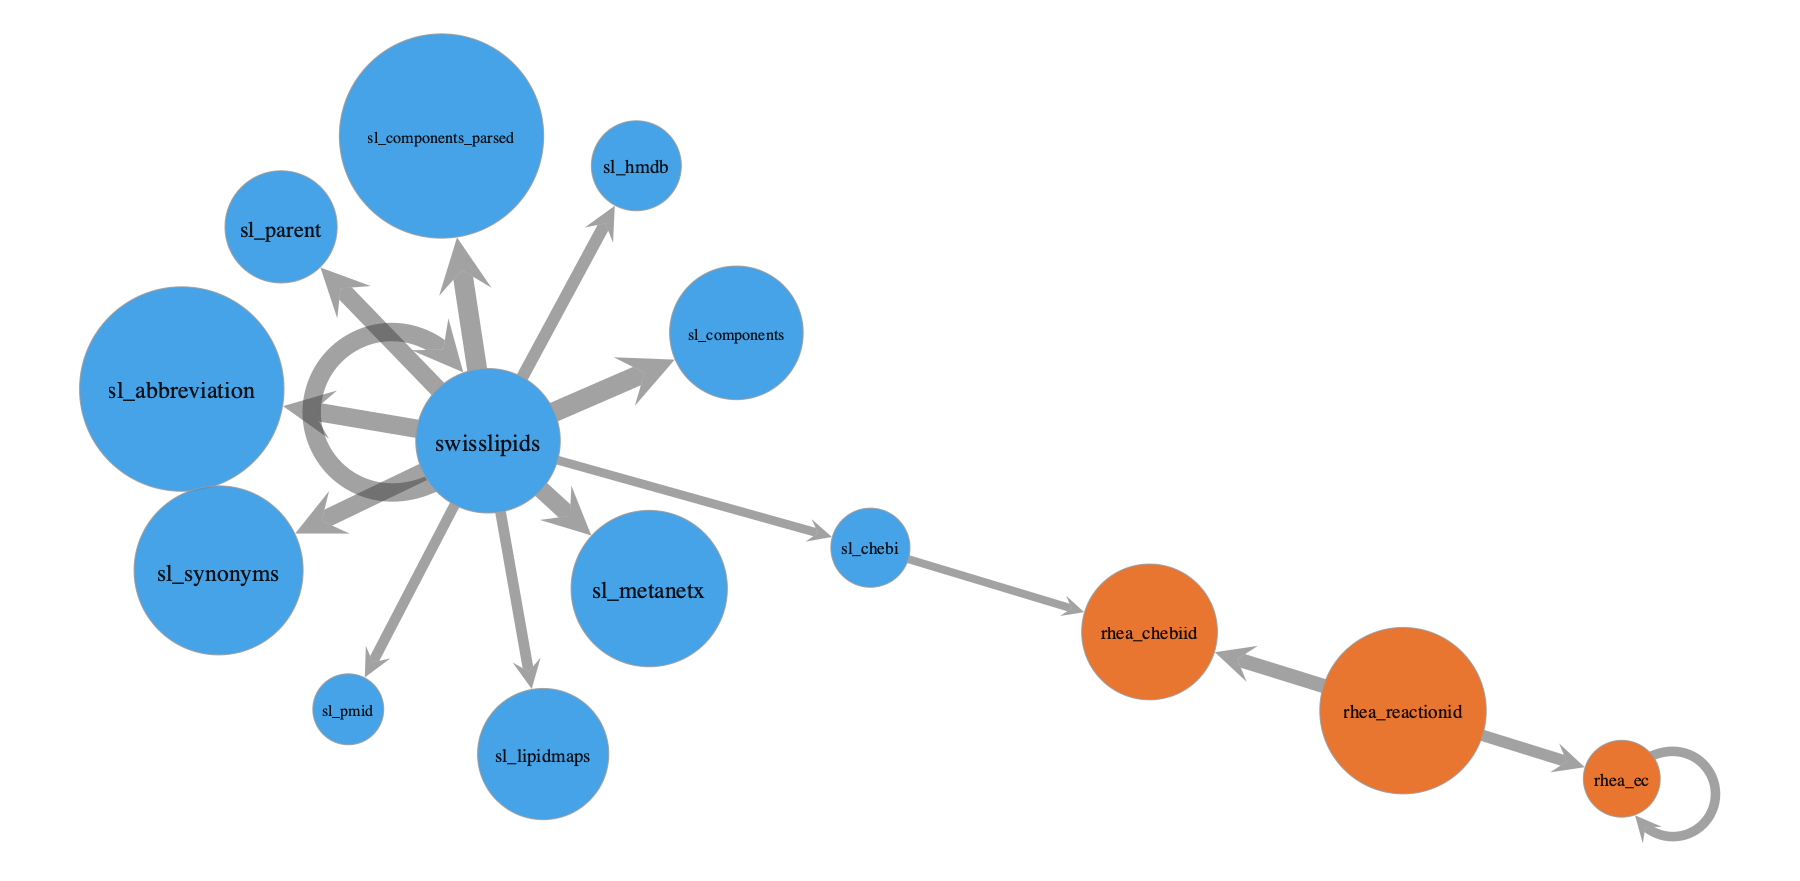

[load]   Loaded layout for 14 rows from .data/.explore_lipinet_pos_sfdp_metagraph.tsv


In [46]:
mg, mg_pos = plot_layer_metagraph(
    edges_by_pair,
    nodes_by_layer=nodes_by_layer,
    node_size_range=(5, 7),
    node_text_size_range=(8, 12),
    edge_width_range=(4, 10),
    node_scaler="log",
    edge_scaler="log",
    show_labels=True,
    # output_size=(1200, 1200),
    node_text_position=-1,
    return_graph=True,
    # pad_label_string=True,
    # vertex_font='consolas',
    family_extractor=my_family,
    family_colors={"sl": (0.2,0.6,0.9,0.9), "rhea": (0.9,0.4,0.1,0.9)}
)

pos_sfdp_metagraph = onionnet.visualisation.load_or_compute_layout(mg, filename='.data/.explore_lipinet_pos_sfdp_metagraph.tsv', override=False) #, inject=mg_pos

Okay, so here we see the different kinds of relationships between layers in LipiNet. Some things we can note:

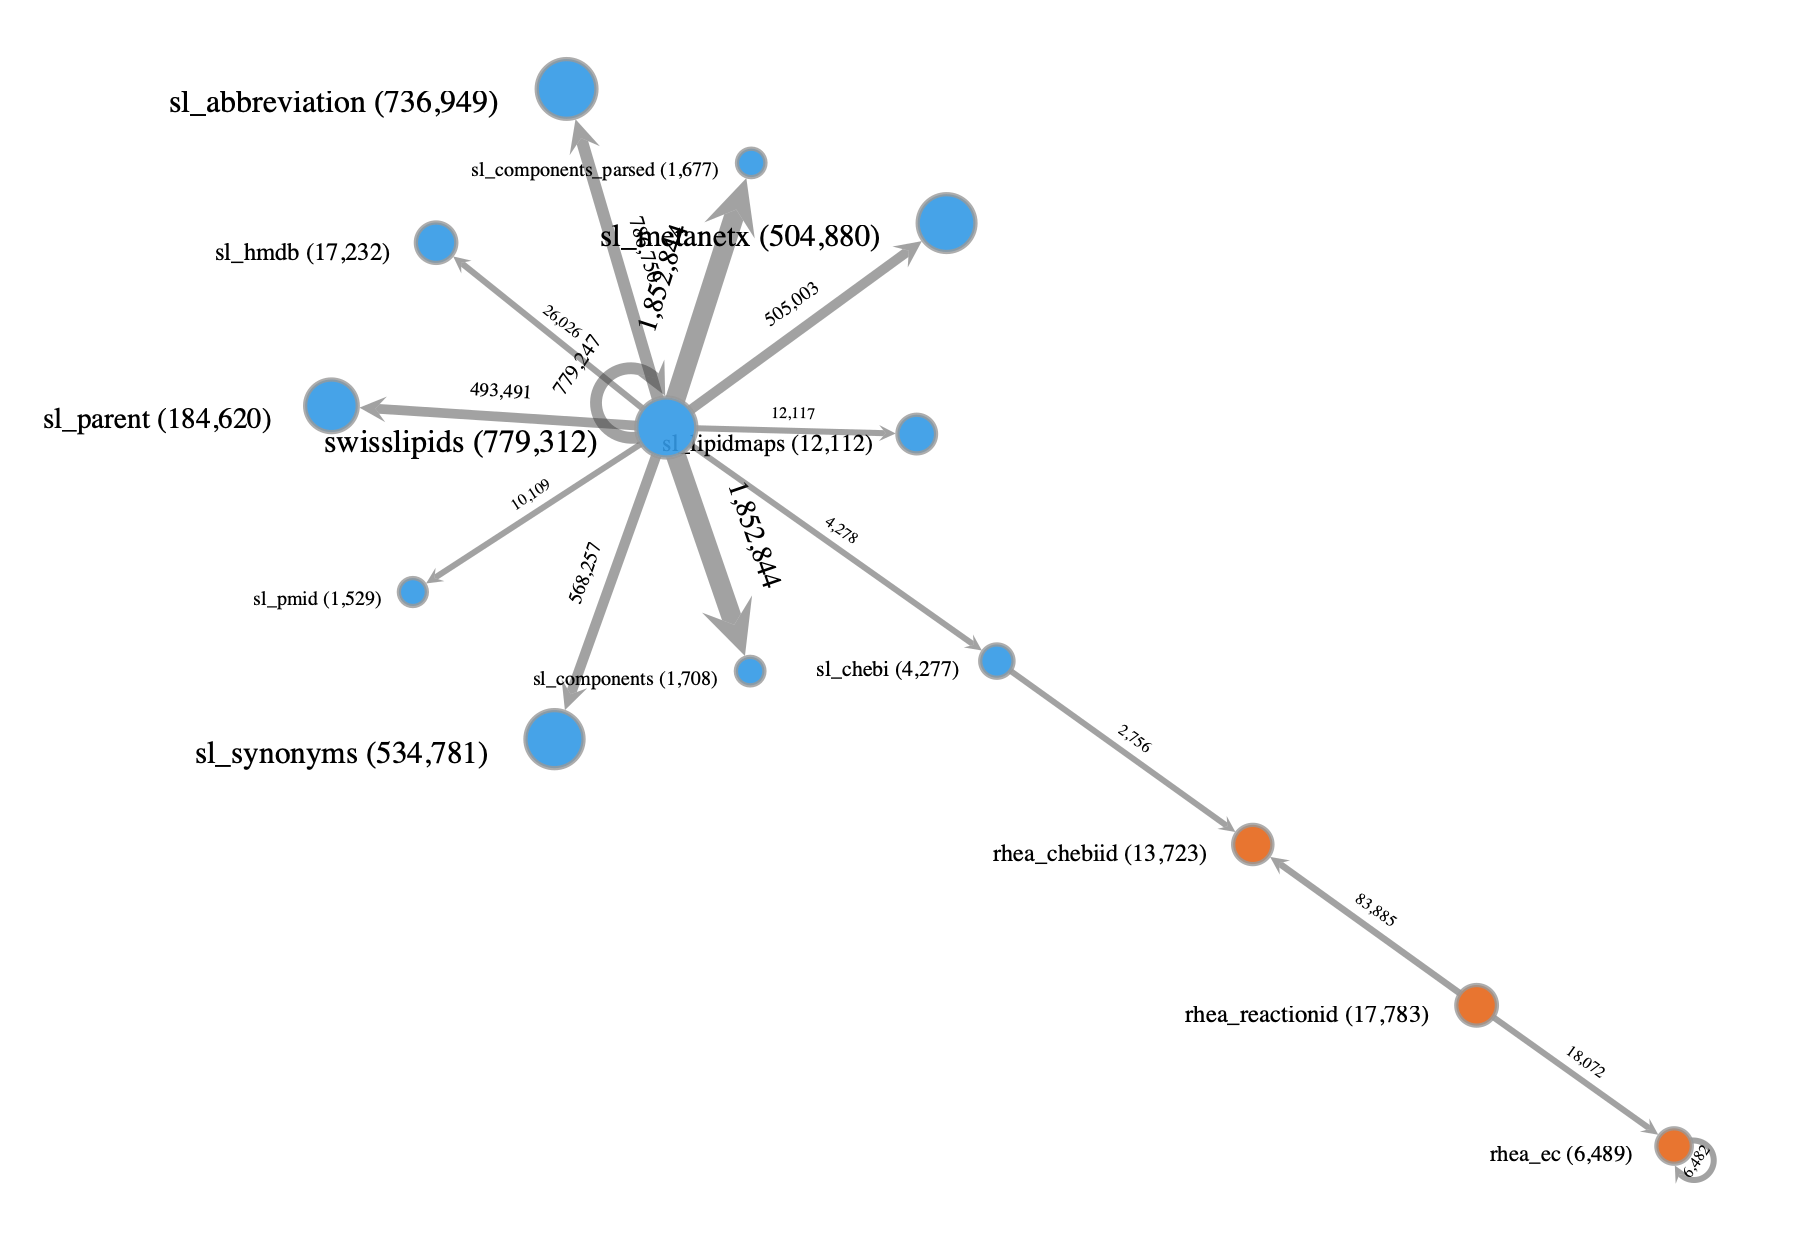

In [7]:
plot_layer_metagraph(
    edges_by_pair, nodes_by_layer,
    node_scaler="log", node_size_range=(14, 30),
    show_edge_counts=True,
    show_node_counts=True,
    node_text_position=3, #'centered', #"centered",
    node_label_fmt= "{layer} ({count})",
    edge_scaler="linear", edge_width_range=(3, 10),
    return_graph=False,
    pos=pos_sfdp_metagraph,
    layout=None,
    show_labels=True,
    family_extractor=my_family,
    family_colors={"sl": (0.2,0.6,0.9,0.9), "rhea": (0.9,0.4,0.1,0.9)}
)

This is admittedly a bit cluttered given the number of different layers. Nonetheless, in combination with the results from the `layer_stats()` function run earlier, this MetaGraph should help get a better understanding of the overall composition of LipiNet, including the number of nodes and edges in or between each layer and the relationships between them.

### Filtering LipiNet

The network we just built contains millions of nodes and edges...

In [8]:
str(onion.g)

'<Graph object, directed, with 2817072 vertices and 6991939 edges, 43 internal vertex properties, 8 internal edge properties, at 0x3feef3e30>'

Let's use the OnionNet filtering functionality to confirm what we see above and double check how many nodes there are in different layers. To do this, let's first decode the vertex `node_id` and `layer` that were encoded behind the scenes for efficiency when OnionNet built the network.

In [9]:
onion.decode_property_labels_bulk(df_nodes[['node_id','layer']], encoded_prop_type='v')

V property 'node_id_decoded' created successfully.
V property 'layer_decoded' created successfully.


In [10]:
pd.Series(onion.g.vp['layer_decoded']).value_counts()

swisslipids             779312
sl_abbreviation         736949
sl_synonyms             534781
sl_metanetx             504880
sl_parent               184620
rhea_reactionid          17783
sl_hmdb                  17232
rhea_chebiid             13723
sl_lipidmaps             12112
rhea_ec                   6489
sl_chebi                  4277
sl_components             1708
sl_components_parsed      1677
sl_pmid                   1529
Name: count, dtype: int64

We see that there are:
- 13723 chebi IDs from Rhea
- 4277 chebi IDs from SwissLipids

We can also filter our network to only include these layers.

First for just swisslipid ChEBIs:

In [11]:
onion.view_layers('sl_chebi')

<GraphView object, directed, with 4277 vertices and 0 edges, 45 internal vertex properties, 8 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x178d210a0, at 0x3e04c5bb0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x178d210a0, at 0x3e04c5c70>, False), at 0x178d210a0>

Then for just Rhea ChEBIs:

In [12]:
onion.view_layers('rhea_chebiid')

<GraphView object, directed, with 13723 vertices and 0 edges, 45 internal vertex properties, 8 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x3e04c5430, at 0x84afcbfb0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x3e04c5430, at 0x84afc84d0>, False), at 0x3e04c5430>

Then for both SwissLipids or Rhea ChEBIs:

In [13]:
onion.view_layers(['sl_chebi','rhea_chebiid'])

<GraphView object, directed, with 18000 vertices and 2756 edges, 45 internal vertex properties, 8 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x16591e780, at 0x448e194c0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x16591e780, at 0x448e19400>, False), at 0x16591e780>

But what if we want to get _only_ the nodes from each of these layers that have connections between them? i.e. the _shared_ connections? 

To do this, we can use the `filter_edges_between_categories` function with `mode=both` if we don't mind which direction the connection is coming from, which in this case is arbitrary for LipiNet connections between layers.

In [14]:
onion.filter_edges_between_categories(source_label='sl_chebi', target_label='rhea_chebiid', mode='both')

<GraphView object, directed, with 5512 vertices and 2756 edges, 45 internal vertex properties, 8 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x448e1b830, at 0x84afcb0e0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x448e1b830, at 0x178ef7980>, False), at 0x448e1b830>

It looks like there are 2756 edges, and exactly double the number of nodes, which is a pretty strong indication that each node is probably only connected by one edge to a single other node.

The below plot result further helps show us that there are no apparent multi-mapping issues between SwissLipid and Rhea ChEBIs.

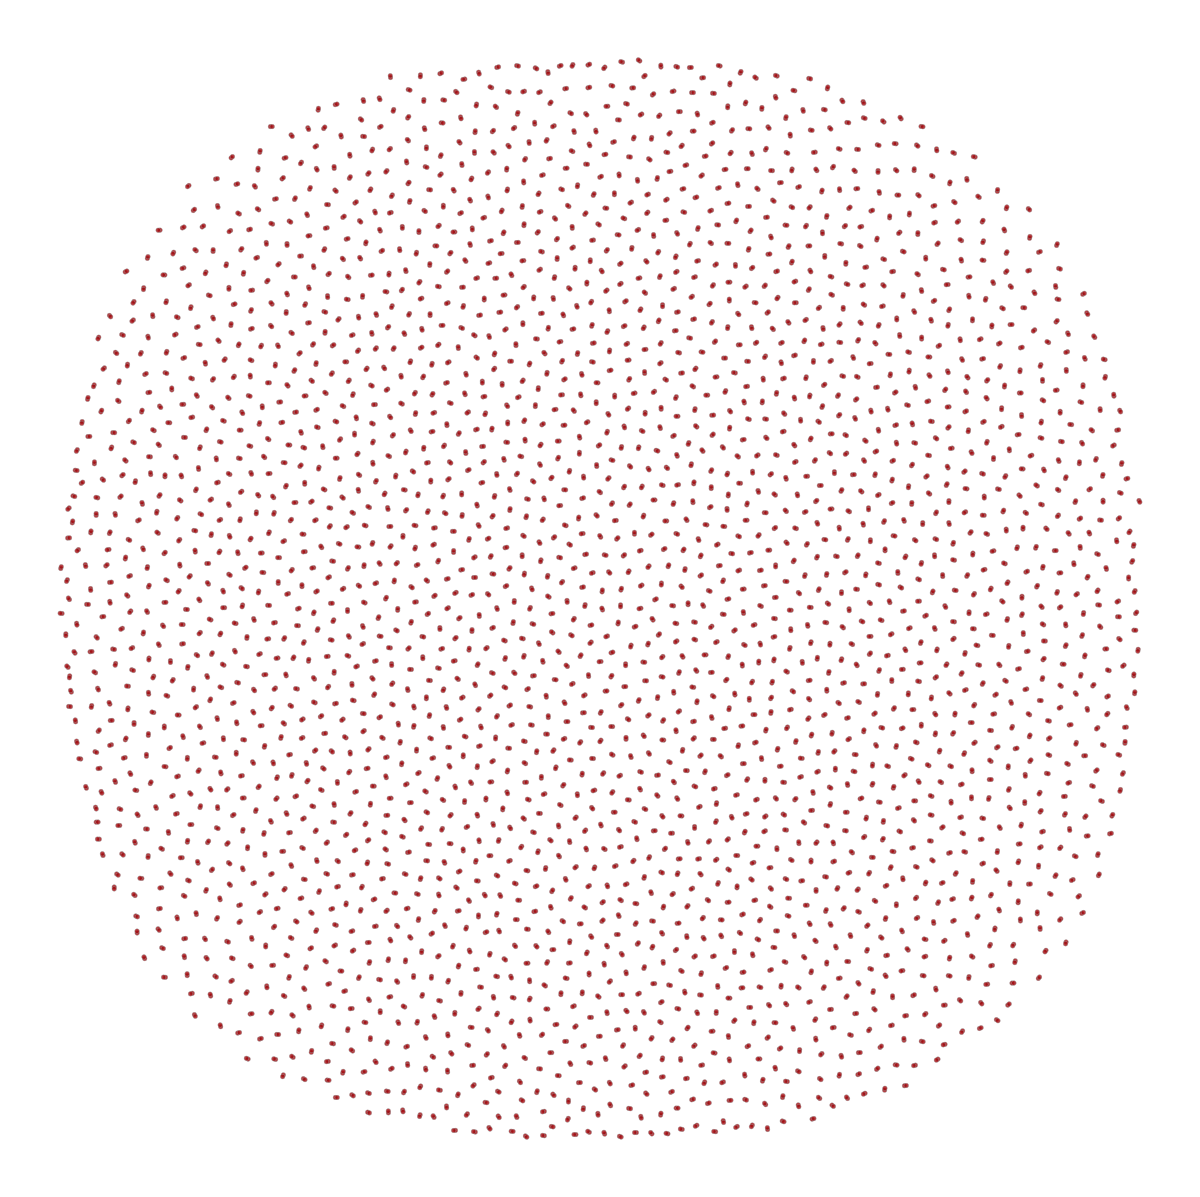

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x3feef3e30, at 0x178e06600>

In [15]:
graph_draw(onion.filter_edges_between_categories(source_label='sl_chebi', target_label='rhea_chebiid', mode='both'))

This example has helped uncover a helpful insight into the linkage between SL and Rhea using ChEBI. However we should note that we could have easily done the same using a dataframe!

Now will move to more complex examples where network representations are much more useful; this is where LipiNet's integration of prior knowledge networks starts to shine.

### Node traversal

Often times we may want to identify a node in LipiNet, then find it's parents or children, and their connections, etc. Or we may want to identify all shortest paths between two or more nodes of interest.

We will consider these two scenarios as:
1. Searching for a specific node
2. Calculating shortest paths between two nodes

In the following subsections we will deal with each of these. But before we do, we will define a function here that we can use to quickly plot stylised graphs with custom graphics for the edge and node properties.

In [16]:
def style_graph(graph_to_style, halo_nodes=[], colors=[(1, 1, 0, 0.6)]):
    origin_colors = {
        "swisslipids": (0.988, 0.733, 0.298, 1.0),   # light golden orange
        "rhea": (0.651, 0.807, 0.890, 1.0),          # pale sky blue
        "lipinet": (1.0, 0.4, 0.4, 1.0),             # red
    }
    layer_shapes = {
        'swisslipids': 'circle',
        'rhea_reactionid': 'square', # 'triangle',
        'sl_chebi': 'pentagon',
        'rhea_chebiid': 'pentagon',
        'sl_hmdb': 'triangle', #non-essential
        'sl_pmid': 'triangle', #non-essential
        'sl_synonyms': 'hexagon', #non-essential
    }

    pm = OnionNetPropertyManager(onion.core)
    pm.decode_property_labels_bulk(
        df=df_nodes[['layer', 'origin_vertex', 'node_id']],
        encoded_prop_type='v',
        g=graph_to_style
    )
    pm.decode_property_labels_bulk(
        df=df_edges[['interlayer', 'origin_edge']],
        encoded_prop_type='e',
        g=graph_to_style
    )

    # Nodes
    color_result = onionnet.visualisation.color_nodes(g=graph_to_style, prop_name="origin_vertex_decoded", method="categorical", generate_legend=True, custom_color_dict=origin_colors) # can also just use 'origin_vertex' if you want to use the encoded property
    shape_result = onionnet.visualisation.shape_nodes(g=graph_to_style, prop_name="layer_decoded", shape_method="categorical", generate_legend=True, custom_shape_dict=layer_shapes)
    halo_result  = onionnet.visualisation.add_halos_to_nodes(g=onion.core.graph, nodes=halo_nodes, colors=colors)

    # Edges
    # edges_interlayer_col = onionnet.visualisation.color_edges(g=graph_to_style, prop_name='interlayer', method='boolean')
    edges_origin_col = onionnet.visualisation.color_edges(g=graph_to_style, prop_name='origin_edge_decoded', method='categorical', generate_legend=True, custom_color_dict=origin_colors) # can also just use 'origin_edge' if you want to use the encoded property

    # Create summary dict for convenience
    graphic_styles = {**color_result, **shape_result, **edges_origin_col, **halo_result}

    # Assign some of the properties that we will likely be using often back to the graph
    graph_to_style.vp['v_color_level'] = graphic_styles['v_color']
    graph_to_style.vp['v_shape_layer'] = graphic_styles['v_shape']
    graph_to_style.ep['e_color_inter'] = graphic_styles['e_color']
    graph_to_style.vp['v_halo'] = graphic_styles['v_halo']
    graph_to_style.vp['v_halo_color'] = graphic_styles['v_halo_color']

    return graphic_styles

#### 1. Searching for a specific node (and parents/children)

__Motivation__ 

Let's say we have a molecule of interest to us: `Vitamin A`. 

More specifically, we are interested in a certain isomer of this: `all-trans-retinol`. In this form, all exocyclic double bonds are in the E configuration (i.e. trans).

We've also know that it is a lipid, and we have found online that it has a CHEBI identifier: `CHEBI:17336`.

But now we want to answer the following questions:
- What reactions does this lipid participate in?
- Does it have a connection in SwissLipids?
- And if so, where does it sit in the SL hierarchical ontology?

__Approach__

LipiNet has both SwissLipids and Rhea already integrated, so we will be well equipped to answer these questions.

To do so, we will use OnionNet to:
1. isolate the node of interest (noi), `CHEBI:17336` in this case, which is part of the `rhea_chebiid` layer
2. use the OnionNet `searcher` functionality, with `upstream` directionality, so that we can get all participating reactions and traverse up the SL ontology
3. style the graph using our previous helper function, and set the halo to be the noi for clear visualisation
4. compute and save a reproducible layout for the graph
5. plot the search results and visualise along with a legend

In [47]:
import cairo
from IPython.display import SVG

Filtered graph contains 38 vertices and 38 edges.
V property 'layer_decoded' created successfully.
V property 'origin_vertex_decoded' created successfully.
V property 'node_id_decoded' created successfully.
interlayer prop left as is, no decoding needed (not an object type)
E property 'origin_edge_decoded' created successfully.
[load]   Loaded layout for 38 rows from .data/.explore_lipinet_pos_sfdp_searchres_CHEBI17336_traverse.tsv


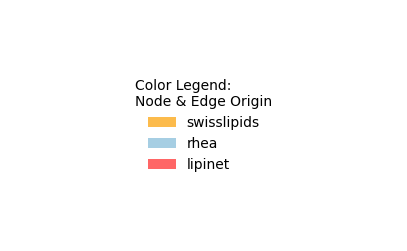

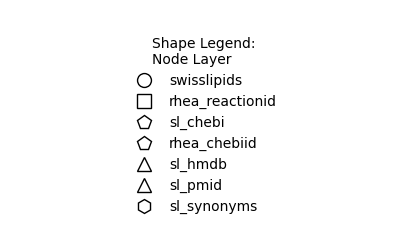

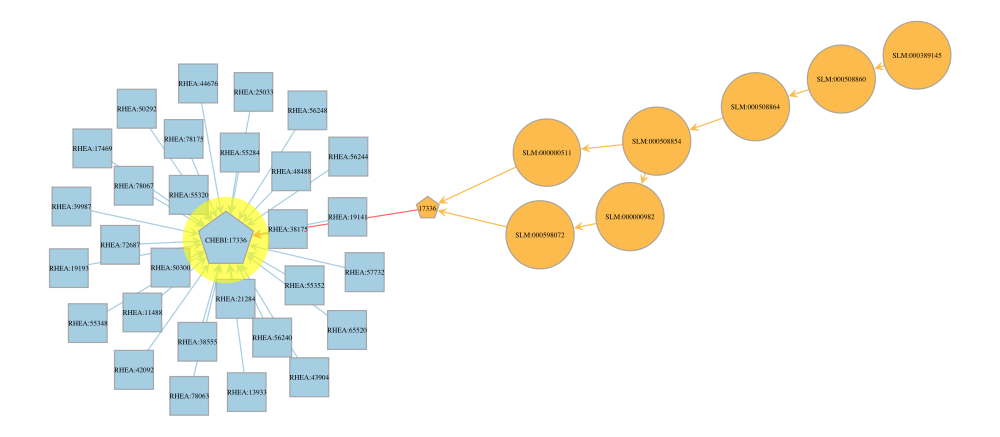

In [61]:
# search for a specific node (noi = node of interest)
noi = onion.get_vertex_by_name_tuple(layer_name='rhea_chebiid', node_id_str='CHEBI:17336')

search_res = onion.searcher.search(start_node_idx=noi, 
                        max_dist=6, 
                        node_text_prop='node_id_decoded',
                        vertex_text_position=-1,
                        vertex_size=14, 
                        output_size=(1000,1000),
                        direction='upstream',
                        show_plot=False
                        )

graphic_styles = style_graph(search_res, halo_nodes=[noi])
pos_sfdp_searchres_CHEBI17336_traverse = onionnet.visualisation.load_or_compute_layout(search_res, filename='.data/.explore_lipinet_pos_sfdp_searchres_CHEBI17336_traverse.tsv', override=False) # note: this needs to be run _after_ the style_graph function to ensure that the vertex properties like node_id_decoded and layer_decoded are set correctly

graph_draw(search_res,
            pos=pos_sfdp_searchres_CHEBI17336_traverse,
            vertex_text=search_res.vp['node_id_decoded'],
            vertex_text_position=-1,
            vertex_size=5,
            # output_size=(1500,1500),
            # vertex_text_color='black',
            output=".data/fig/explore_lipinet_searchres_CHEBI17336_traverse.svg",            # vector output
            output_size=(500, 400),           # pick the page aspect you want
            antialias=cairo.ANTIALIAS_BEST,   # nicer edges
            ink_scale=1.2,                     # slightly thicker strokes for readability
            # here we add the graphics from above
            vertex_fill_color=search_res.vp['v_color_level'],
            vertex_shape=search_res.vp['v_shape_layer'],
            edge_color=search_res.ep['e_color_inter'],
            vertex_halo=search_res.vp['v_halo'],
            vertex_halo_color=search_res.vp['v_halo_color'], 
)

# Note since we used a custom color dict, we can also use the legend function to get the legend for the node and edge colors, whcih should both be the same
# onionnet.visualisation.get_legend(source=graphic_styles['legend_node_color'], title='Legend: Node Origin Colors')
# onionnet.visualisation.get_legend(source=graphic_styles['legend_edge_color'], title='Legend: Edge Origin Colors')
onionnet.visualisation.get_legend(source=graphic_styles['legend_edge_color'], title='Color Legend:\nNode & Edge Origin')
onionnet.visualisation.get_legend(source=graphic_styles['legend_node_shape'], title='Shape Legend:\nNode Layer')
SVG(".data/fig/explore_lipinet_searchres_CHEBI17336_traverse.svg")

__Results__

With this quick search and plot we can now answer each of our original questions

- _What reactions does this lipid participate in?_

  - CHEBI:17336 (i.e. all-trans-retinol) participates in a large number of different reactions (see plot for exact Rhea identifiers). 
  - For example [RHEA:13933](https://www.rhea-db.org/rhea/13934), one of the nodes towards the bottom of the Rhea hub, which is the _undirectional_ reaction for:
    
    > `all-trans-retinyl hexadecanoate + H₂O = all-trans-retinol + hexadecanoate + H⁺`

- _Does it have a connection in SwissLipids?_

  - Yes, CHEBI:17336 is linked to _both_ SLM:000000511 and SLM:000598072 from SL.

- And if so, where does it sit in the SL hierarchical ontology?

  - If we look this up online we can see that SLM:000000511 (all-trans-retinol) is an isomeric subspecies. Whereas SLM:000598072 (all-trans-retinol--[retinol-binding protein]) does not have a SL associated with it.

__Advanced insights__

This example also hints at why making this connection using LipiNet can be helpful to trace from nodes higher in the hierarchy to those lower, since higher levels are less likely to be directly associated with a ChEBI ID. 

For instance, if we had experimentally measured a higher class such as SLM:000508854 (Retinoids), which [when we look up online on SL](https://www.swisslipids.org/#/entity/SLM:000508854/) _does_ actually have a CHEBI ID too (CHEBI:26537), it does _not_ have any interactions/reactions linked to that entity. 

<img src=".data/screenshots/screenshot_swisslipids_SLM000508854.png"
     alt="Screenshot from SwissLipids SLM000508854 search, for comparative purposes. 13 Aug 2025."
     style="max-width:80%; height:auto;">

However if we [search Rhea directly for CHEBI:26537](https://www.rhea-db.org/rhea?query=CHEBI%3A26537) we currently get 86 reactions in our results (as of 12 Aug 2025). And furthermore, these results appear to be for specific isomers or forms of Retinoids. 

_So what is going on here? Why does SwissLipids not have any links to Rhea for the lipid class with that ChEBI ID, but Rhea is returning results for that same ChEBI ID?_ 

<img src=".data/screenshots/screenshot_rhea_CHEBI26537.png"
     alt="Screenshot from Rhea CHEBI26537 search, for comparative purposes. 13 Aug 2025."
     style="max-width:80%; height:auto;">

The reason for this discrepancy is that technically Rhea is computed at the exact level, i.e. the major microspecies at pH 7.3, to make it more biologically realistic.

__But often times, the measurements we have of lipidomics in real world settings are not at the isomeric level__. 

Rhea [acknowledges this complexity and deals with it by using the ChEBI ontology](https://www.rhea-db.org/help/search-rhea-chebi-class) to find specific reactions and participants from more general terms. For instance, the Rhea search functionality can use `lipid` to find all reactions involving lipids, by using the ChEBI ontology.

<img src=".data/screenshots/screenshot_rhea_search_chebi_class.png"
     alt="Screenshot from Rhea search chebi about, for comparative purposes. 13 Aug 2025."
     style="max-width:80%; height:auto;">

In contrast, it appears the SwissLipids browser does not (currently) have this built in capability on their web browser (and it could be argued that it could be needlessly inefficient in that scenario anyway).

Nonetheless, this is exactly __LipiNet can, and must, be used to make possible connections between higher levels of the ontology and the prior knowledge.__

This is shown below.

Filtered graph contains 142 vertices and 231 edges.
V property 'layer_decoded' created successfully.
V property 'origin_vertex_decoded' created successfully.
V property 'node_id_decoded' created successfully.
interlayer prop left as is, no decoding needed (not an object type)
E property 'origin_edge_decoded' created successfully.
[load]   Loaded layout for 142 rows from .data/.explore_lipinet_pos_sfdp_searchres_SLM000508854_traverse.tsv


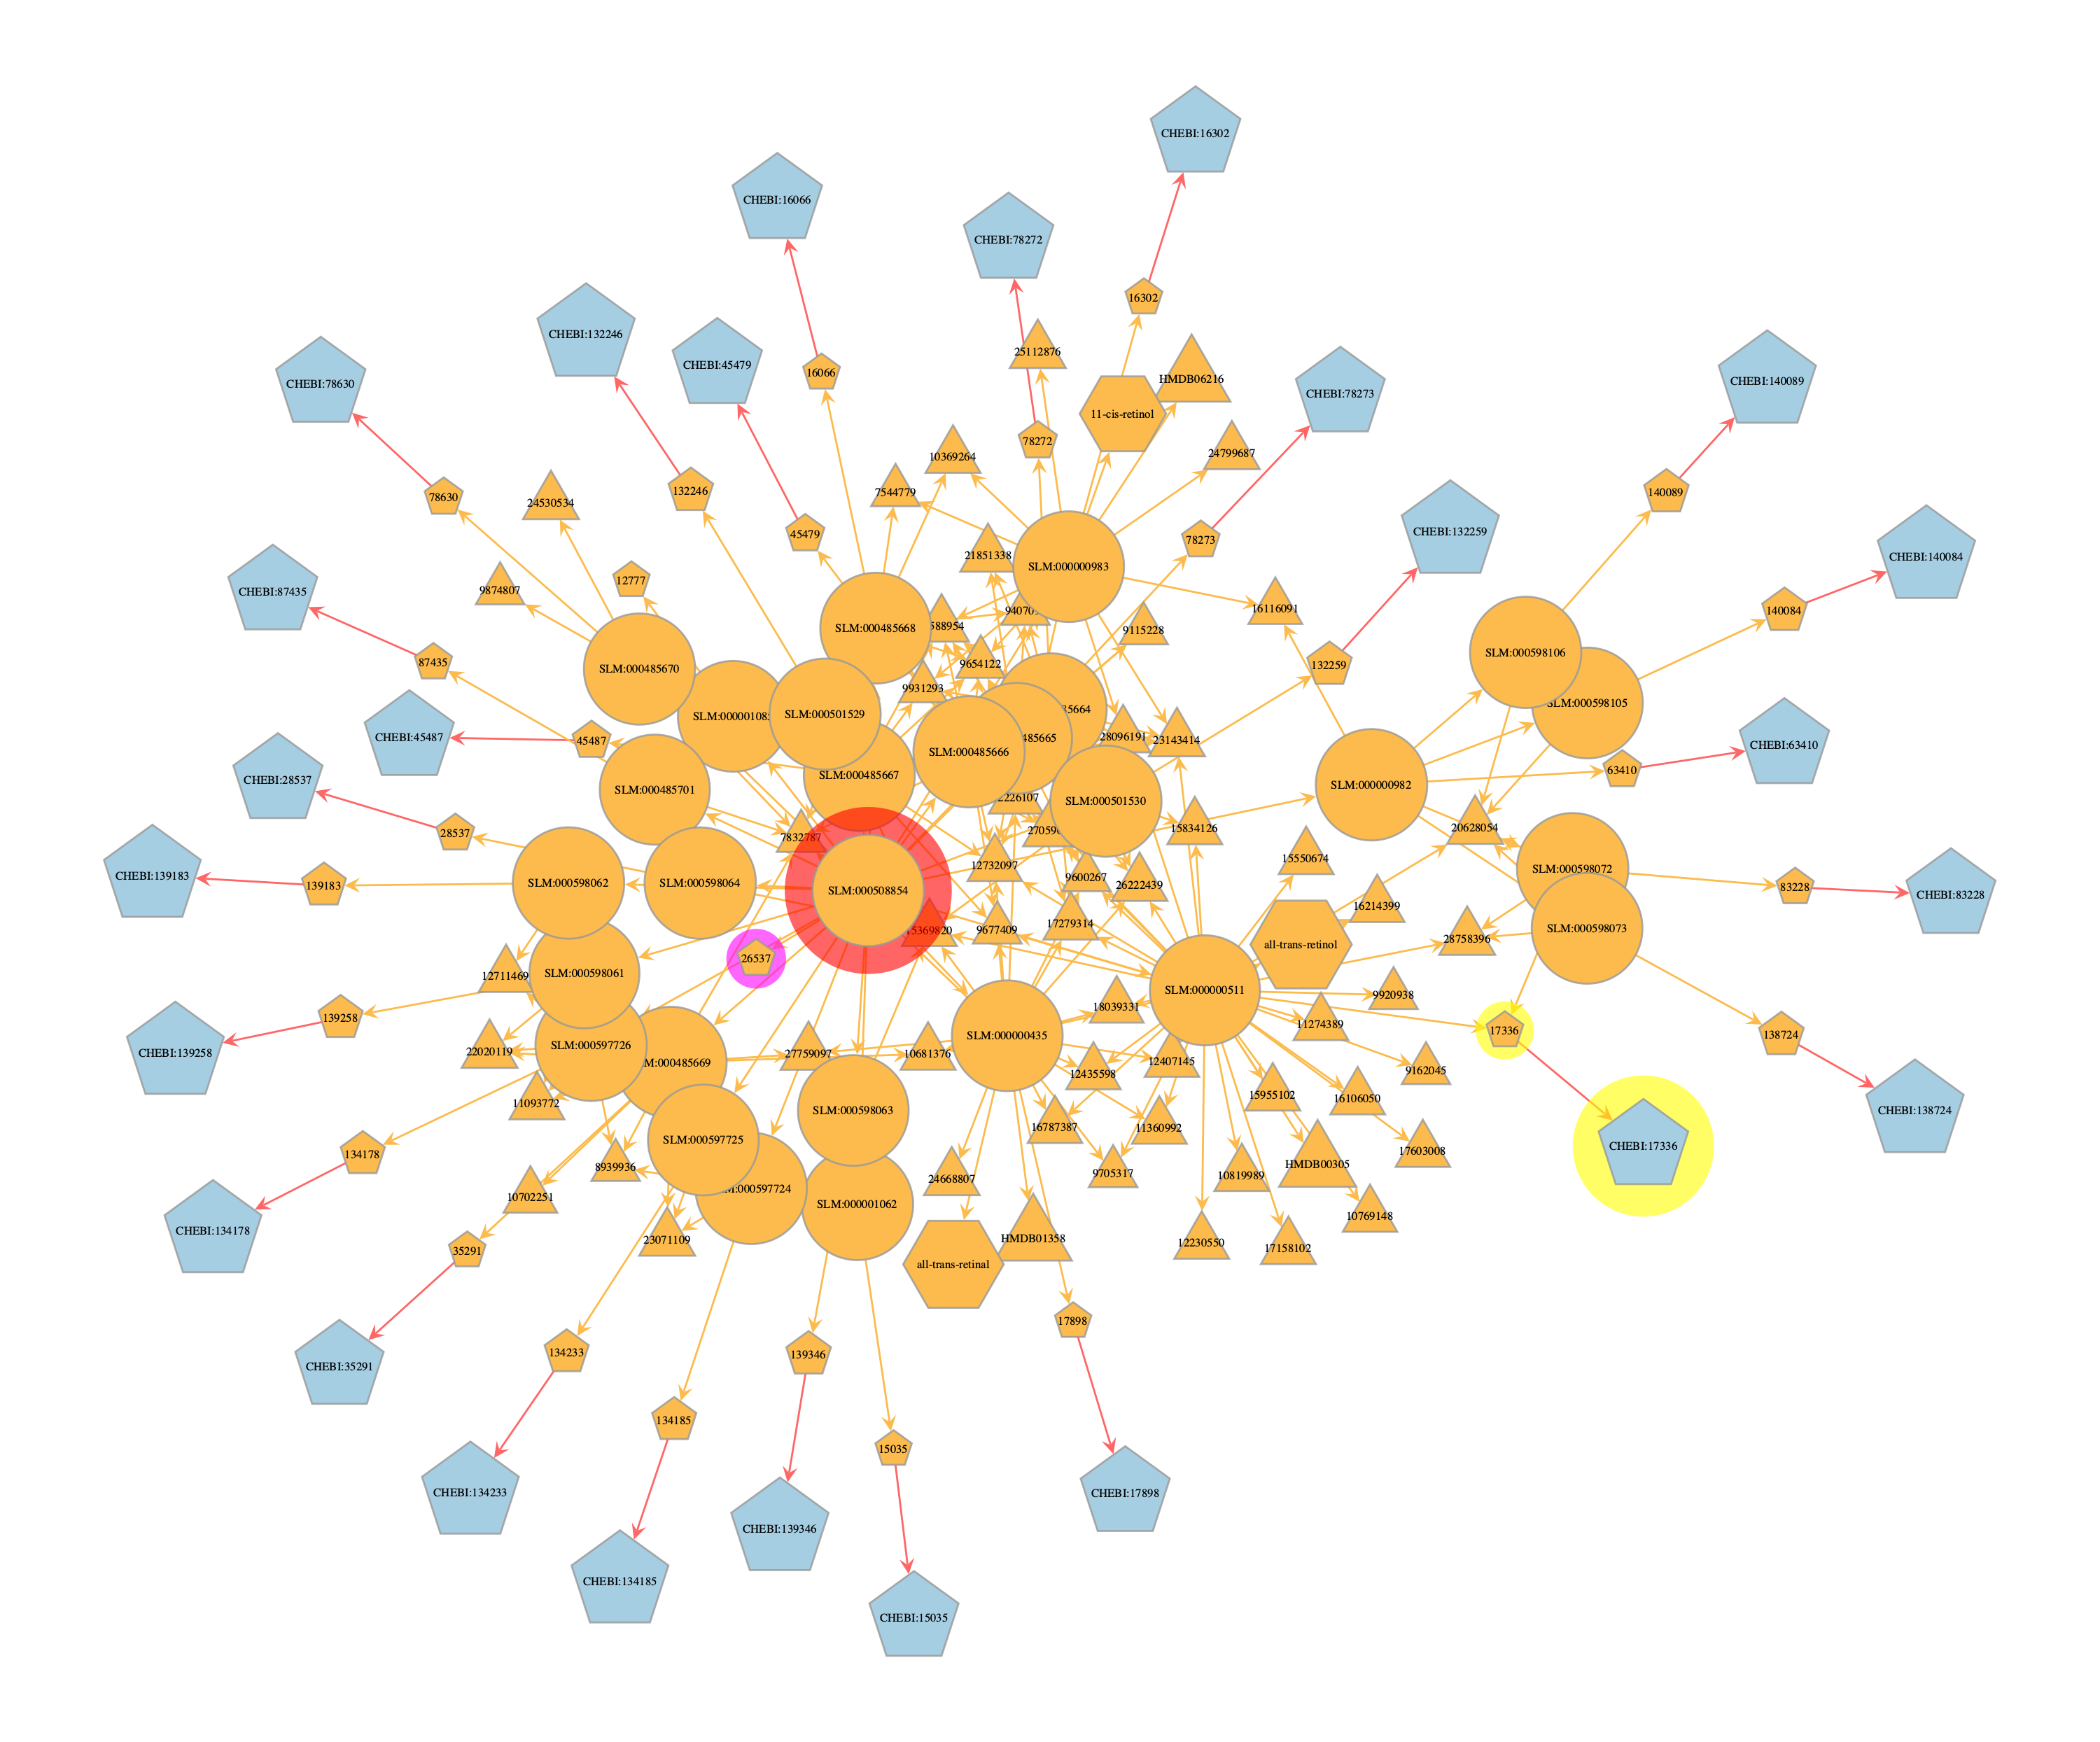

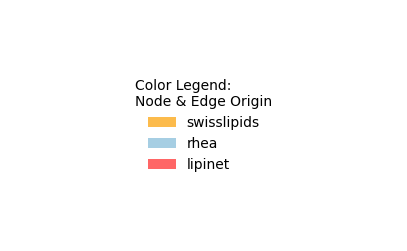

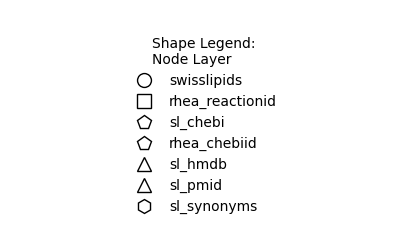

In [18]:
# search for a specific node (noi = node of interest)
noi = onion.get_vertex_by_name_tuple(layer_name='swisslipids', node_id_str='SLM:000508854') # higher level node, SL Retinoid entry
noi2 = onion.get_vertex_by_name_tuple(layer_name='rhea_chebiid', node_id_str='CHEBI:17336') # Rhea CHEBI ID with connection to lower level SL CHEBI ID (noi3)
noi3 = onion.get_vertex_by_name_tuple(layer_name='sl_chebi', node_id_str='17336') # SL CHEBI ID with connection to lower level SL all-trans-retinol entry
noi4 = onion.get_vertex_by_name_tuple(layer_name='sl_chebi', node_id_str='26537') # SL CHEBI ID with connection to SL Retinoid entry (noi)


search_res = onion.searcher.search(start_node_idx=noi, 
                        max_dist=6, 
                        node_text_prop='node_id_decoded',
                        vertex_text_position=-1,
                        vertex_size=14, 
                        output_size=(1000,1000),
                        direction='downstream',
                        show_plot=False
                        )

graphic_styles = style_graph(search_res, halo_nodes=[noi, noi2, noi3, noi4], colors=[(1, 0, 0, 0.6), (1, 1, 0, 0.6), (1, 1, 0, 0.6), (1, 0, 1, 0.6)])
pos_sfdp_searchres_SLM000508854_traverse = onionnet.visualisation.load_or_compute_layout(search_res, filename='.data/.explore_lipinet_pos_sfdp_searchres_SLM000508854_traverse.tsv', override=False) # note: this needs to be run _after_ the style_graph function to ensure that the vertex properties like node_id_decoded and layer_decoded are set correctly

graph_draw(search_res,
            pos=pos_sfdp_searchres_SLM000508854_traverse,
            vertex_text=search_res.vp['node_id_decoded'],
            vertex_text_position=-1,
            vertex_size=14,
            output_size=(1500,1500),
            # vertex_text_color='black',
            # here we add the graphics from above
            vertex_fill_color=search_res.vp['v_color_level'],
            vertex_shape=search_res.vp['v_shape_layer'],
            edge_color=search_res.ep['e_color_inter'],
            vertex_halo=search_res.vp['v_halo'],
            vertex_halo_color=search_res.vp['v_halo_color'], 
)

# Note since we used a custom color dict, we can also use the legend function to get the legend for the node and edge colors, whcih should both be the same
# onionnet.visualisation.get_legend(source=graphic_styles['legend_node_color'], title='Legend: Node Origin Colors')
# onionnet.visualisation.get_legend(source=graphic_styles['legend_edge_color'], title='Legend: Edge Origin Colors')
onionnet.visualisation.get_legend(source=graphic_styles['legend_edge_color'], title='Color Legend:\nNode & Edge Origin')
onionnet.visualisation.get_legend(source=graphic_styles['legend_node_shape'], title='Shape Legend:\nNode Layer')

__Conclusion__

This plot above confirms that the [SL Retinoid class (SLM:000508854)](https://www.swisslipids.org/#/entity/SLM:000508854/)(red halo), connects directly to the SL CHEBI:26537 ID. However the CHEBI:26537 ID (purple halo) does not directly link to any downstream entities or reactions, etc. When we search for it in the graph for the rhea chebi ID layer, it does not return anything.

In [19]:
try:
    onion.get_vertex_by_name_tuple(layer_name='rhea_chebiid', node_id_str='CHEBI:26537')
except Exception as e:
    print("❗ Could not find the node with id 'CHEBI:26537' on the `rhea_chebiid` layer in the graph. Please check the node id and layer name.")
    # raise e

❗ Could not find the node with id 'CHEBI:26537' on the `rhea_chebiid` layer in the graph. Please check the node id and layer name.


Whereas in contrast, the more specific [SL all-trans-retinol isomeric subspecies (SLM:000000511)](https://www.swisslipids.org/#/entity/SLM:000000511/) links directly to the SL CHEBI:17336 ID (yellow halo). This in turn is linked to the Rhea CHEBI:17336 entry, and from there to all the downstream Rhea reactions.

This highlights the importance of using ontologies such as ChEBI or SwissLipids to link terms. Some tools already have this functionality baked in to their back-ends, but LipiNet aims to support this more broadly across various ontologies, for direct use in analyses and visualisations.

#### 2. Calculating shortest paths between two nodes of interest

__Motivation__

In the first plot from our previous example, we saw how our node of interest (CHEBI:17336), eventually connected back to the root 'Lipid' node from SwissLipids (SLM:000389145).

Along the path, we saw that it was also connected to other nodes in the SL hierarchy, like all-trans-retinol, the retinoid class, and other in the hierarchy.

But what if we also wanted to find other possible connections back to the root node? 

__Approach__

We can find all possible shortest paths between two nodes of interest in LipiNet by using the OnionNet `searcher.compute_on_shortest()` function.

1. Isolate the nodes of interest
2. Pass these to the `compute_on_shortest` method

<GraphView object, directed, with 16 vertices and 17 edges, 47 internal vertex properties, 8 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x469577fe0, at 0x94e795b50>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x469577fe0, at 0x448e19d90>, False), at 0x469577fe0>
V property 'layer_decoded' created successfully.
V property 'origin_vertex_decoded' created successfully.
V property 'node_id_decoded' created successfully.
interlayer prop left as is, no decoding needed (not an object type)
E property 'origin_edge_decoded' created successfully.
[load]   Loaded layout for 16 rows from .data/.explore_lipinet_pos_sfdp_searchres_SLM000389145_CHEBI17336.tsv


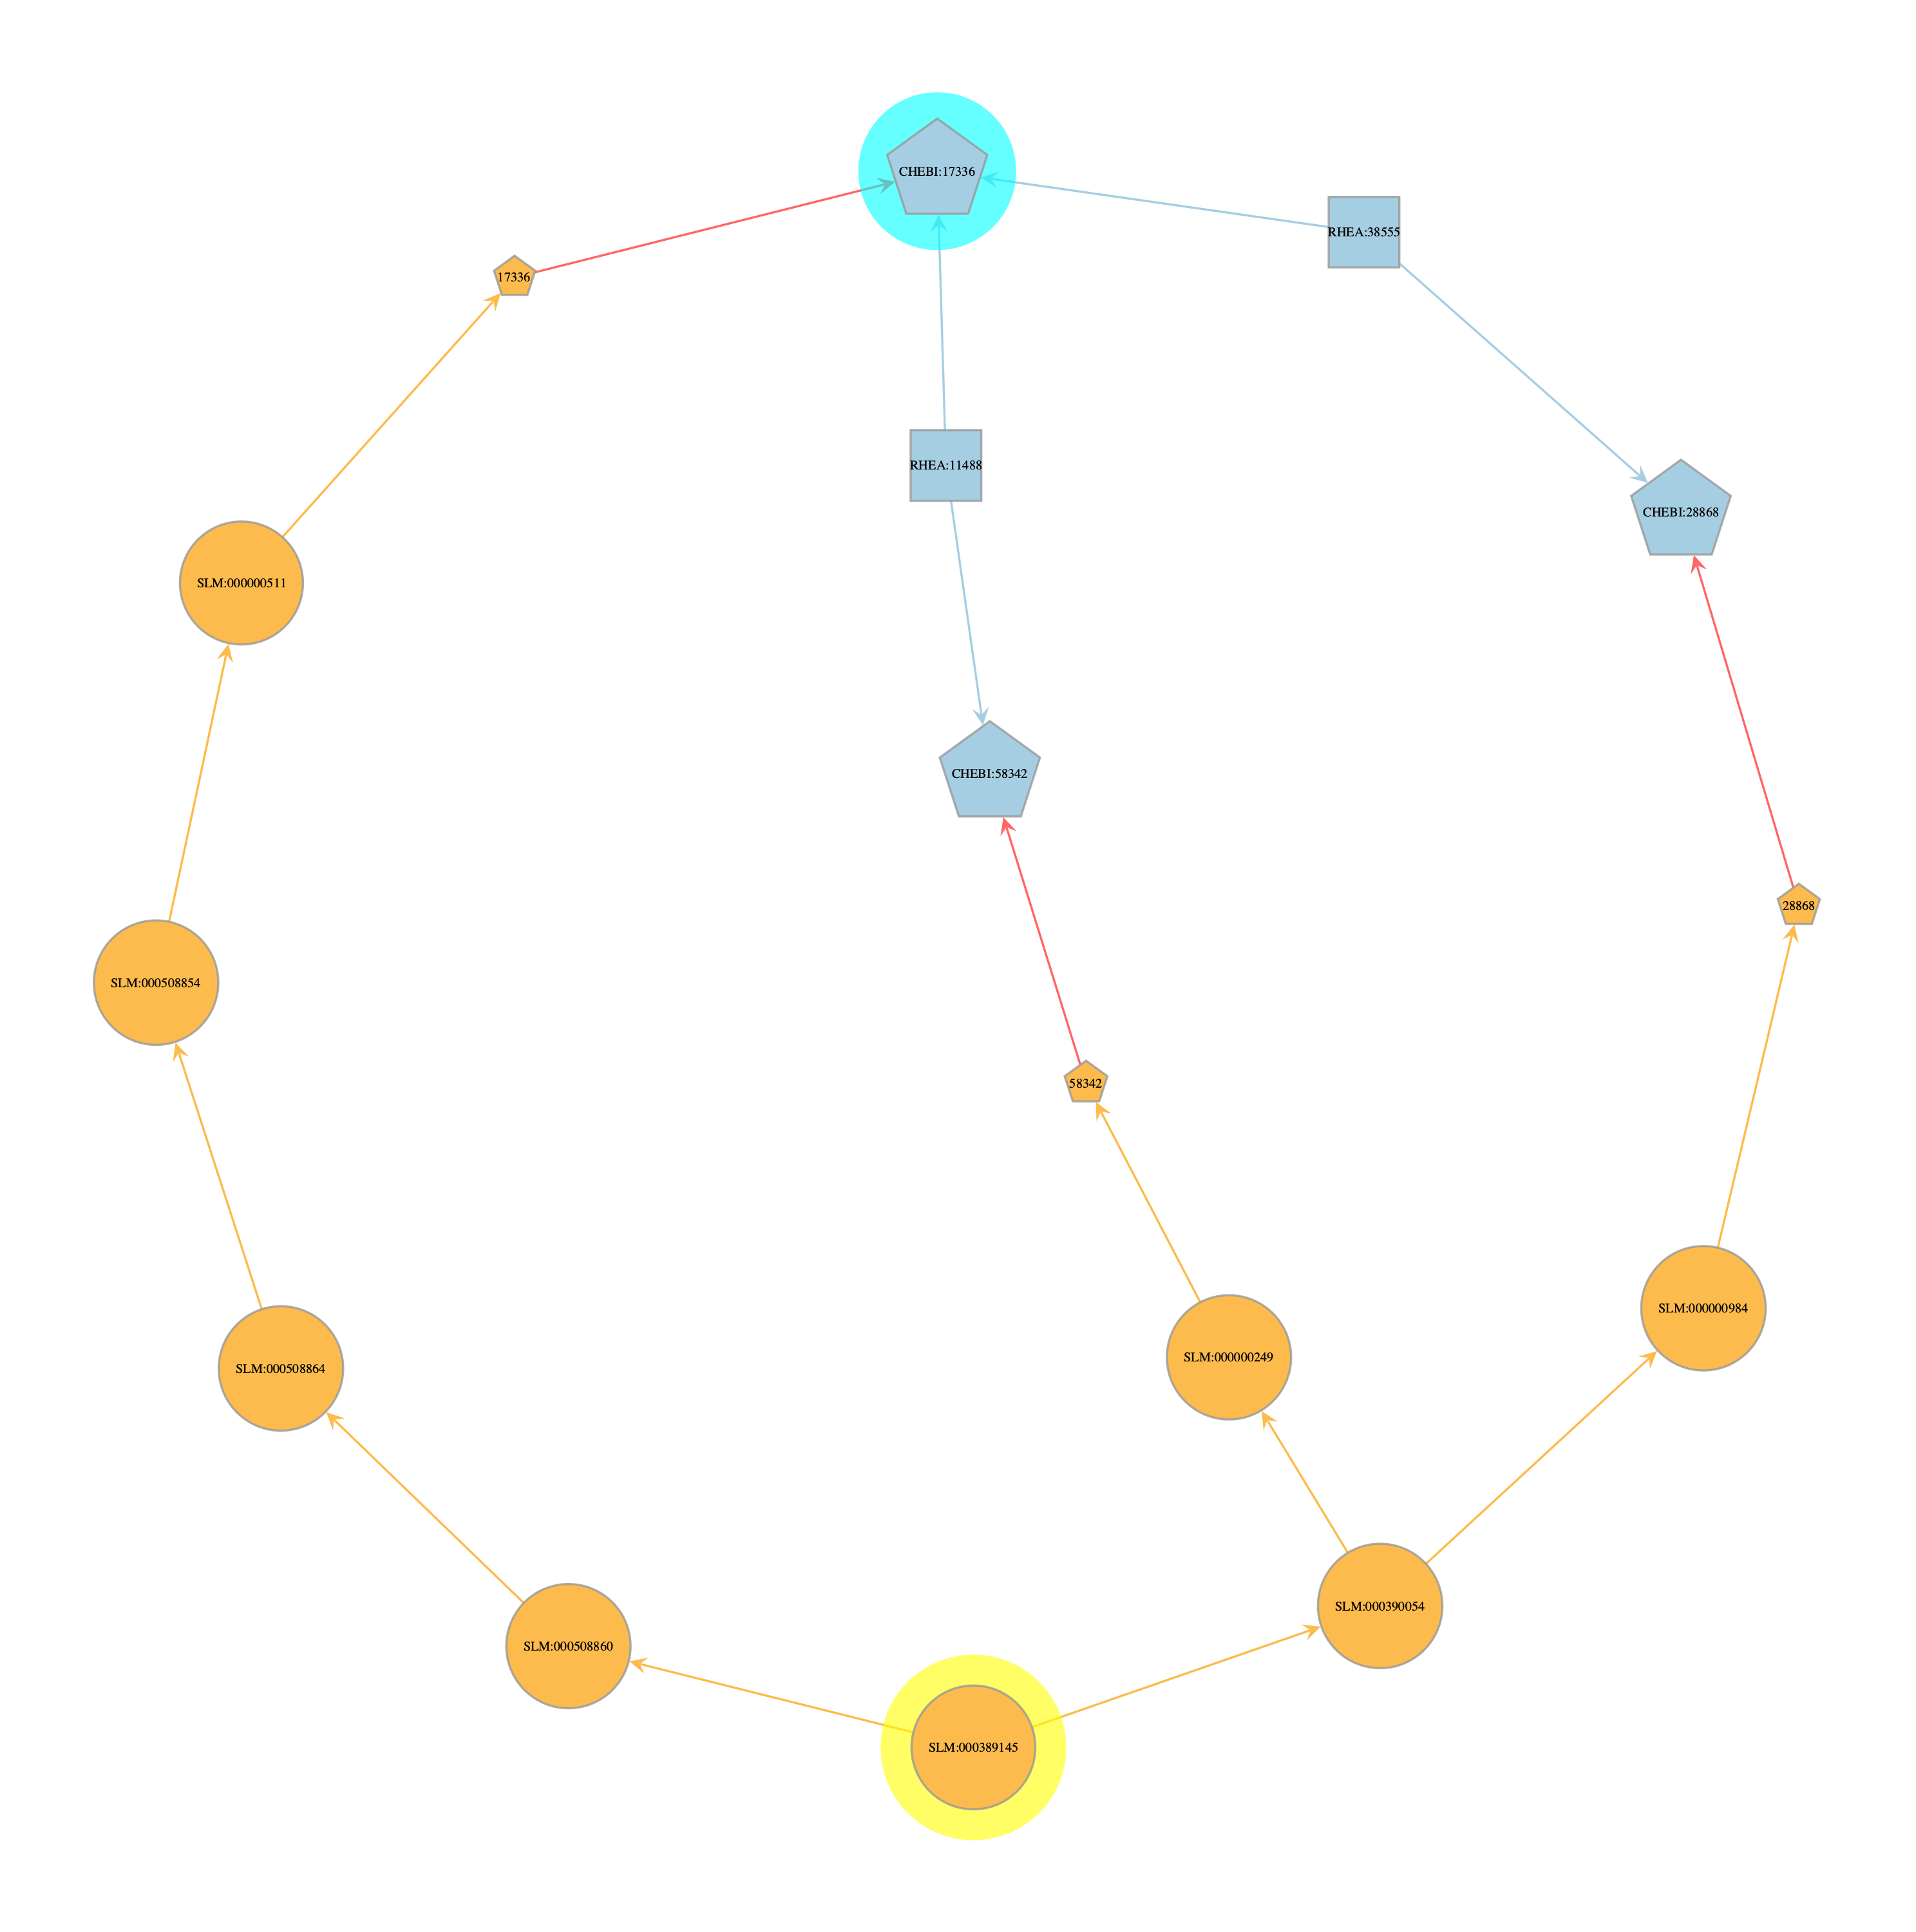

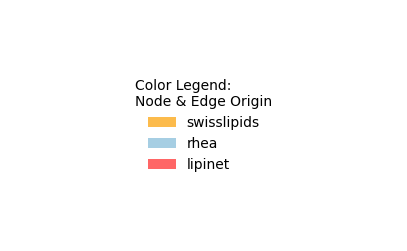

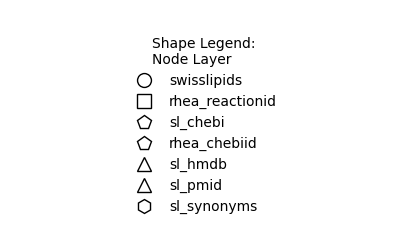

In [20]:
noi_a = onion.get_vertex_by_name_tuple(layer_name='swisslipids', node_id_str='SLM:000389145')
noi_b = onion.get_vertex_by_name_tuple(layer_name='rhea_chebiid', node_id_str='CHEBI:17336')

search_res = onion.searcher.compute_on_shortest(g=onion.g, source=noi_a, targets=[noi_b], return_gv=True, directed=False)
print(search_res)

graphic_styles = style_graph(search_res, halo_nodes=[noi_a, noi_b], colors=[(1, 1, 0, 0.6), (0, 1, 1, 0.6)])
pos_sfdp_searchres_SLM000389145_CHEBI17336 = onionnet.visualisation.load_or_compute_layout(search_res, filename='.data/.explore_lipinet_pos_sfdp_searchres_SLM000389145_CHEBI17336.tsv', override=False) # note: this needs to be run _after_ the style_graph function to ensure that the vertex properties like node_id_decoded and layer_decoded are set correctly

graph_draw(search_res,
            pos = pos_sfdp_searchres_SLM000389145_CHEBI17336,
            vertex_text=search_res.vp['node_id_decoded'],
            vertex_text_position=-1,
            vertex_size=17,
            output_size=(1500,1500),
            vertex_text_color='black',
            # here we add the graphics from above
            vertex_fill_color=search_res.vp['v_color_level'],
            vertex_shape=search_res.vp['v_shape_layer'],
            edge_color=search_res.ep['e_color_inter'],
            vertex_halo=search_res.vp['v_halo'],
            vertex_halo_color=search_res.vp['v_halo_color'], 
)
onionnet.visualisation.get_legend(source=graphic_styles['legend_edge_color'], title='Color Legend:\nNode & Edge Origin')
onionnet.visualisation.get_legend(source=graphic_styles['legend_node_shape'], title='Shape Legend:\nNode Layer')

From this graph we can make the following observations:
- CHEBI:17336 (all-trans-retinol) has only 1 _direct_ connection back to SwissLipids (which was already confirmed in our earlier analysis)
- two of the other shortest paths back to the SL root node are formed from lipids that are also co-participants in reactions with CHEBI:17336
  - middle: [SLM:000000249](https://www.swisslipids.org/#/entity/SLM:000000249/) - Fatty acyl-CoAs
  - right: [SLM:000000249](https://www.swisslipids.org/#/entity/SLM:000000984/) - Fatty acids

These two other shortest paths aren't all that informative in this case, but highlight an interesting point: many lipid reactions (or reactions in general) involve products that are extremely unspecific and/or cannot be easily measured in reactions. Running shortest paths in this case is also more likely to return these kind of linkages passing through unspecific molecules to the user because these link to very high levels of the corresponding swisslipids ontology. This isn't a bug, but is something we might want to consider when evaluating results. In the future, LipiNet may also support the optional removal of these kinds of unspecific molecules - however knowing where to draw the line could be impossible to determine, and for now we leave it to user discretion to keep this in mind when analysing their data.

We can also find shortest paths between say a reaction and the lipid root node, in a similar way to before.

<GraphView object, directed, with 24 vertices and 27 edges, 47 internal vertex properties, 8 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x3e04c78f0, at 0x4695b9550>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x3e04c78f0, at 0x4695b8bf0>, False), at 0x3e04c78f0>
V property 'layer_decoded' created successfully.
V property 'origin_vertex_decoded' created successfully.
V property 'node_id_decoded' created successfully.
interlayer prop left as is, no decoding needed (not an object type)
E property 'origin_edge_decoded' created successfully.
[load]   Loaded layout for 24 rows from .data/.explore_lipinet_pos_sfdp_searchres_SLM000389145_RHEA19193.tsv


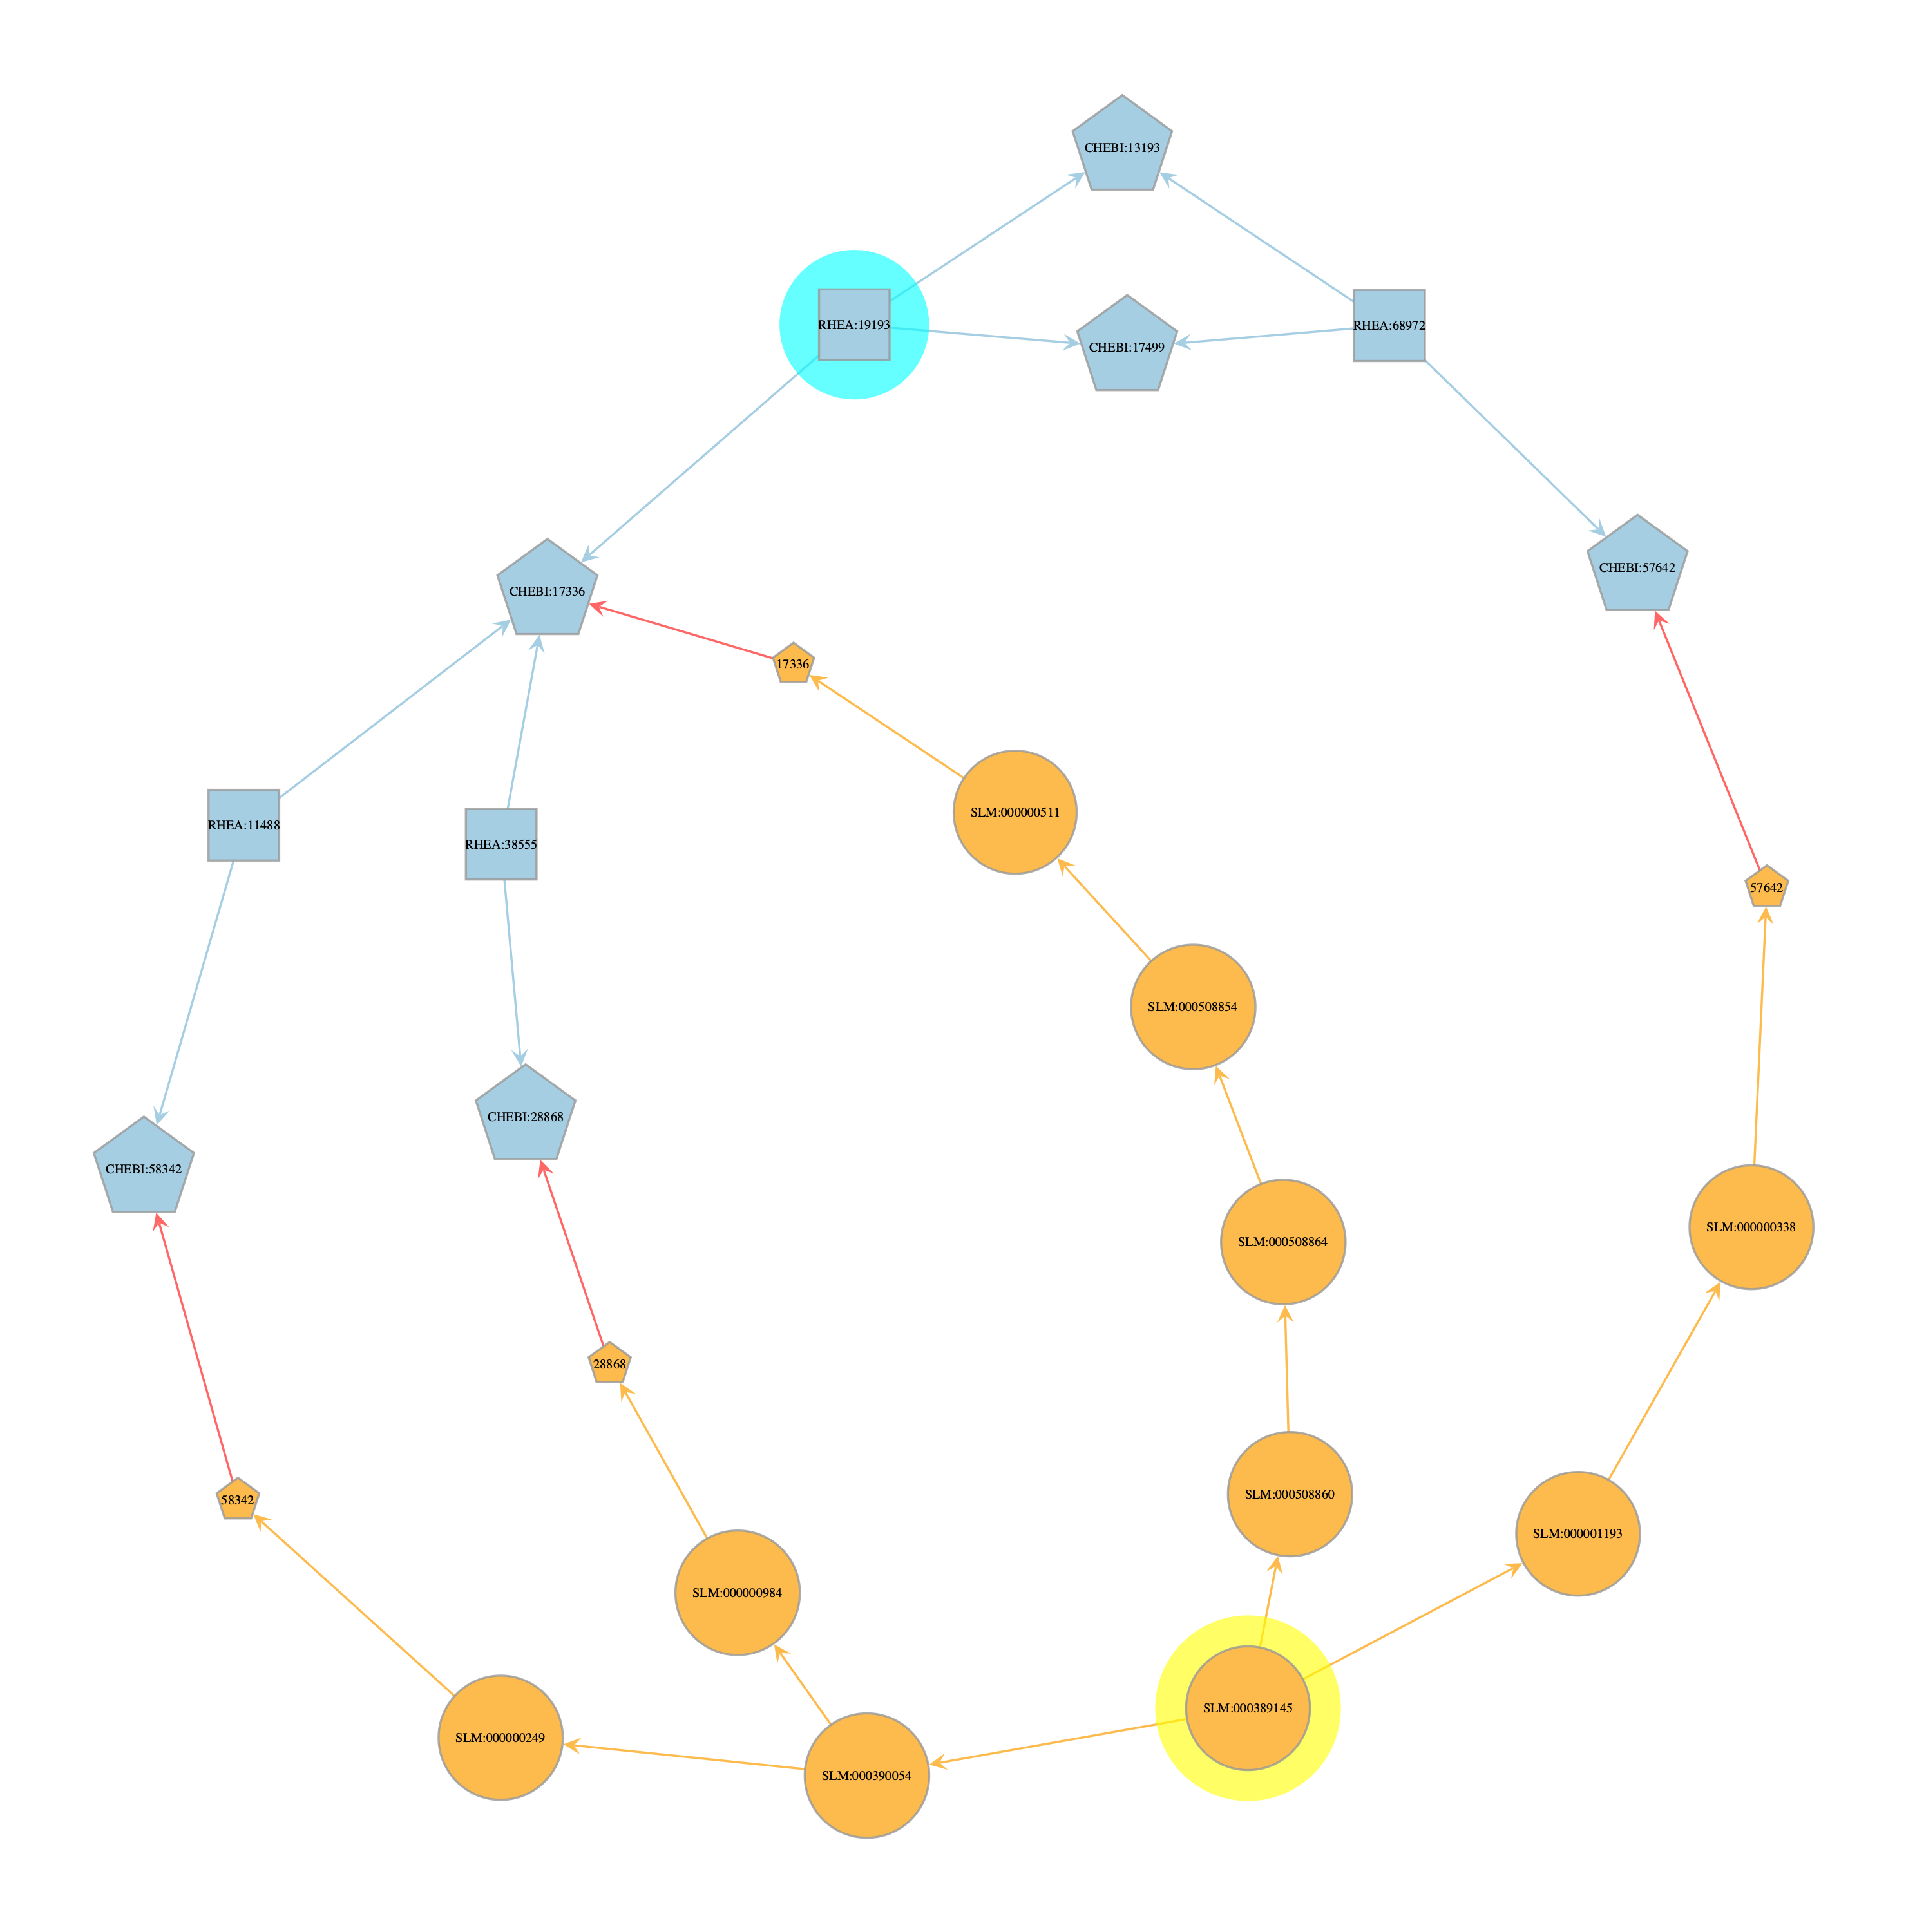

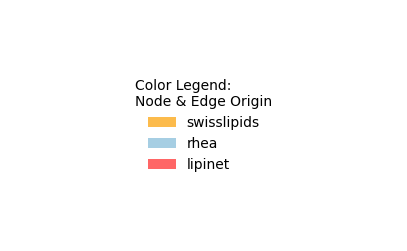

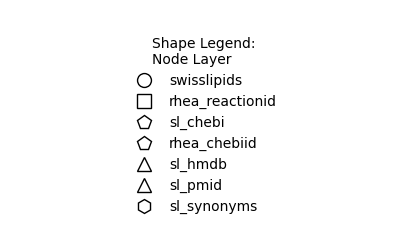

In [21]:
noi_a =  onion.get_vertex_by_name_tuple(layer_name='swisslipids', node_id_str='SLM:000389145')
noi_b = onion.get_vertex_by_name_tuple(layer_name='rhea_reactionid', node_id_str='RHEA:19193')

search_res = onion.searcher.compute_on_shortest(g=onion.g, source=noi_a, targets=[noi_b], return_gv=True, directed=False)
print(search_res)

style_graph(search_res, halo_nodes=[noi_a, noi_b], colors=[(1, 1, 0, 0.6), (0, 1, 1, 0.6)])
pos_sfdp_searchres_SLM000389145_RHEA19193 = onionnet.visualisation.load_or_compute_layout(search_res, filename='.data/.explore_lipinet_pos_sfdp_searchres_SLM000389145_RHEA19193.tsv', override=False)


graph_draw(search_res,
            pos = pos_sfdp_searchres_SLM000389145_RHEA19193,
            vertex_text=search_res.vp['node_id_decoded'],
            vertex_text_position=-1,
            vertex_size=17,
            output_size=(1500,1500),
            vertex_text_color='black',
            # here we add the graphics from above
            vertex_fill_color=search_res.vp['v_color_level'],
            vertex_shape=search_res.vp['v_shape_layer'],
            edge_color=search_res.ep['e_color_inter'],
            vertex_halo=search_res.vp['v_halo'],
            vertex_halo_color=search_res.vp['v_halo_color'], 
)
onionnet.visualisation.get_legend(source=graphic_styles['legend_edge_color'], title='Color Legend:\nNode & Edge Origin')
onionnet.visualisation.get_legend(source=graphic_styles['legend_node_shape'], title='Shape Legend:\nNode Layer')

Lastly, another way we can visualise this is by layer.

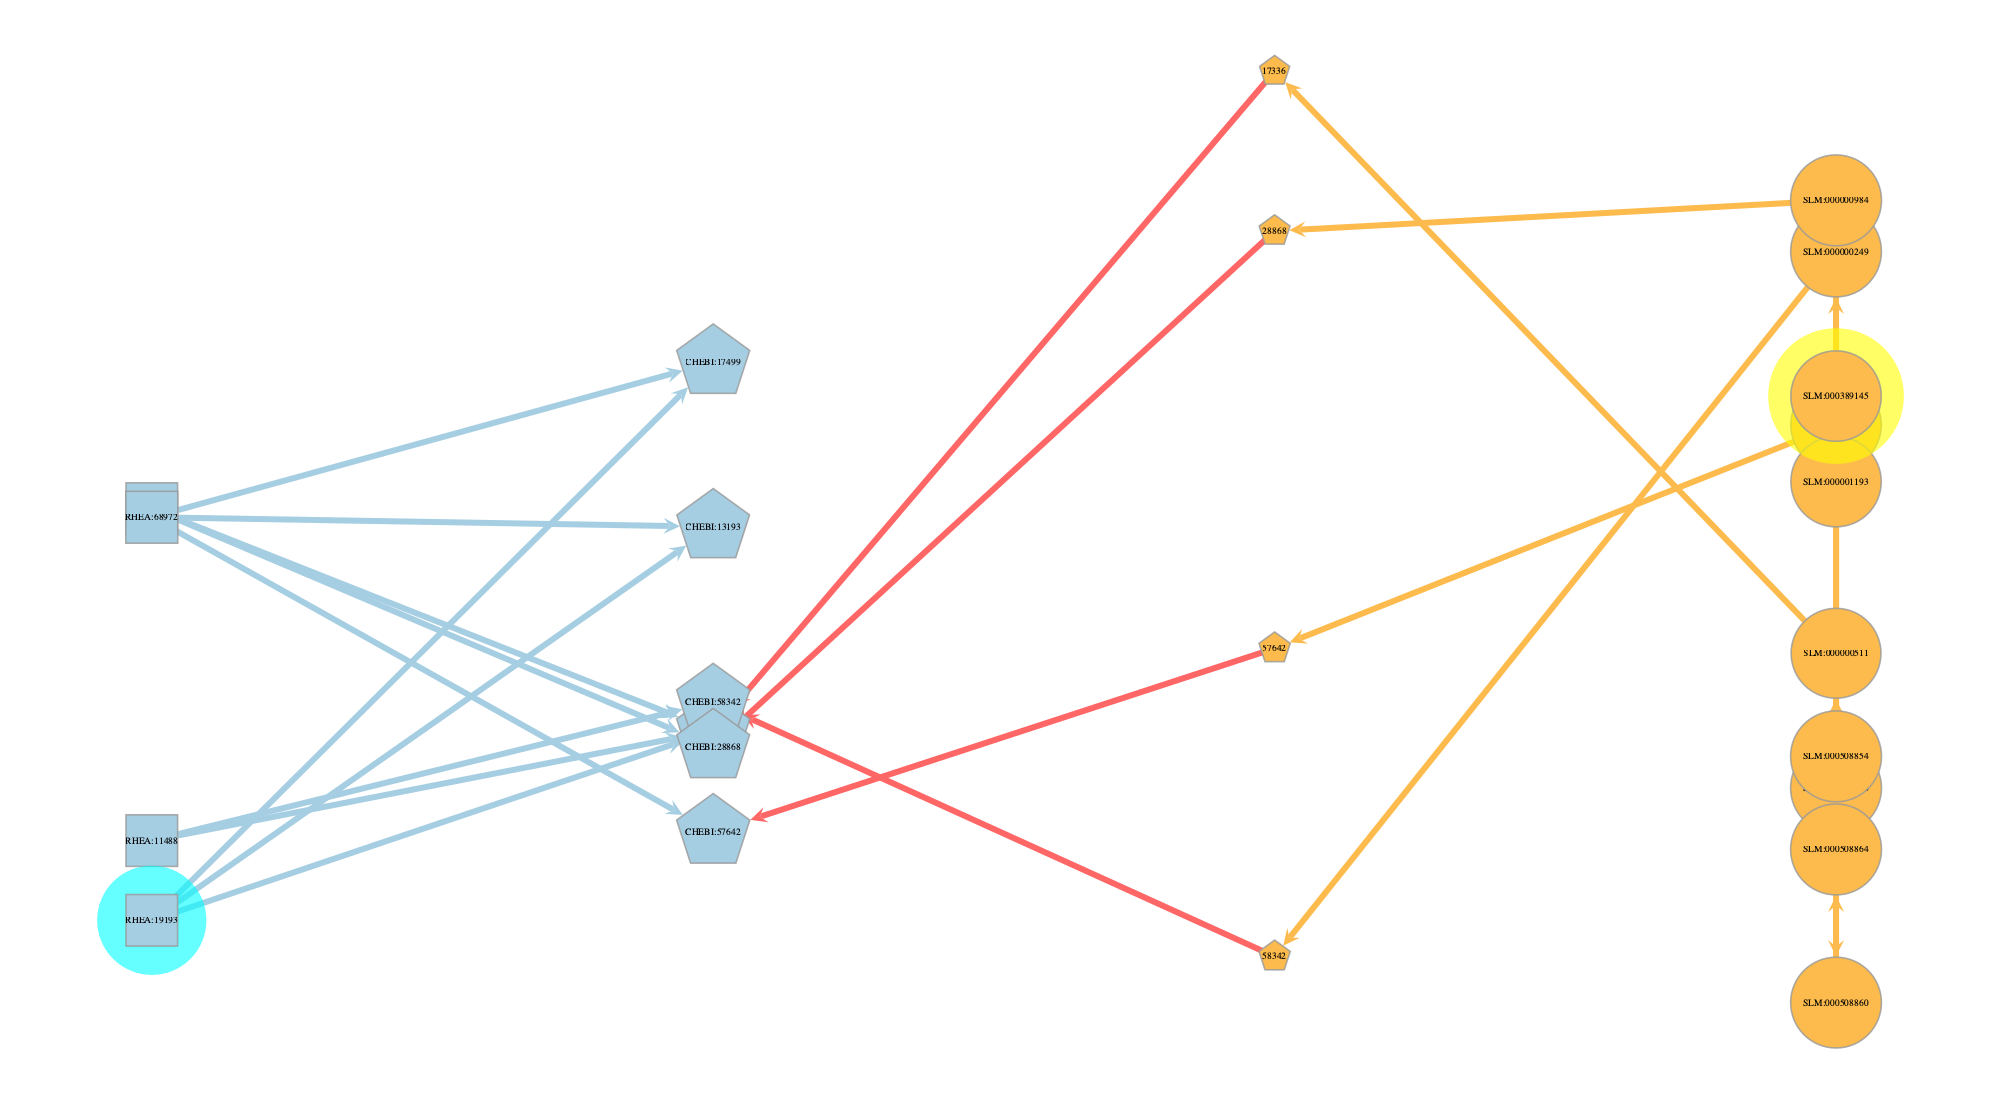

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x3e04c78f0, at 0x867893800>

In [22]:
pos_by_layer = onionnet.visualisation.layout_by_layer(search_res, layer_prop_name='layer', spacing=20, epsilon=10)
graph_draw(search_res,
            pos=pos_by_layer,
            output_size=(1000, 1000),
            edge_pen_width=3,
            vertex_size=8,
            vertex_text=search_res.vp['node_id_decoded'],
            vertex_fill_color=search_res.vp['v_color_level'],
            vertex_shape=search_res.vp['v_shape_layer'],
            edge_color=search_res.ep['e_color_inter'],
            vertex_halo=search_res.vp['v_halo'],
            vertex_halo_color=search_res.vp['v_halo_color'], 
            nodesfirst=False)

## Conclusion

Here we have explored only a very minute subsection of LipiNet. These functions should provide you with a helpful template to get started with LipiNet and if you have any questions or concerns please get in touch.